In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,DayOfWeek,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,December,Tuesday,7,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,December,Tuesday,7,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,December,Tuesday,7,0


In [3]:
monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales["InvoiceDate"] = monthly_sales["InvoiceDate"].astype(str)

monthly_sales.head()

,InvoiceDate,Revenue
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192


In [4]:
forecast_data = monthly_sales.rename(
    columns={
        "InvoiceDate":"ds",
        "Revenue":"y"
    }
)

forecast_data["ds"] = pd.to_datetime(forecast_data["ds"])

forecast_data.head()

,ds,y
0,2009-12-01,686654.160
1,2010-01-01,557319.062
2,2010-02-01,506371.066
3,2010-03-01,699608.991
4,2010-04-01,594609.192


In [6]:
model = Prophet()

model.fit(forecast_data)

19:38:11 - cmdstanpy - INFO - Chain [1] start processing
19:38:11 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = model.make_future_dataframe(
    periods=6,
    freq="M"
)

future.tail()

C:\Users\Anjishnu Chatterjee\AppData\Roaming\Python\Python313\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
26,2012-01-31
27,2012-02-29
28,2012-03-31
29,2012-04-30
30,2012-05-31


In [8]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,762588.159170,711265.997725,842557.383202,762588.159170,762588.159170,11575.667356,11575.667356,11575.667356,11575.667356,11575.667356,11575.667356,0.0,0.0,0.0,774163.826526
1,2010-01-01,761753.413423,464019.600178,604961.698202,761753.413423,761753.413423,-230199.747762,-230199.747762,-230199.747762,-230199.747762,-230199.747762,-230199.747762,0.0,0.0,0.0,531553.665661
2,2010-02-01,760918.667709,402688.755723,532659.299294,760918.667709,760918.667709,-293484.994955,-293484.994955,-293484.994955,-293484.994955,-293484.994955,-293484.994955,0.0,0.0,0.0,467433.672753
3,2010-03-01,760164.703792,598321.414409,731431.129207,760164.703792,760164.703792,-96326.452442,-96326.452442,-96326.452442,-96326.452442,-96326.452442,-96326.452442,0.0,0.0,0.0,663838.251350
4,2010-04-01,759329.958064,514832.272920,641080.982882,759329.958064,759329.958064,-183354.144035,-183354.144035,-183354.144035,-183354.144035,-183354.144035,-183354.144035,0.0,0.0,0.0,575975.814029


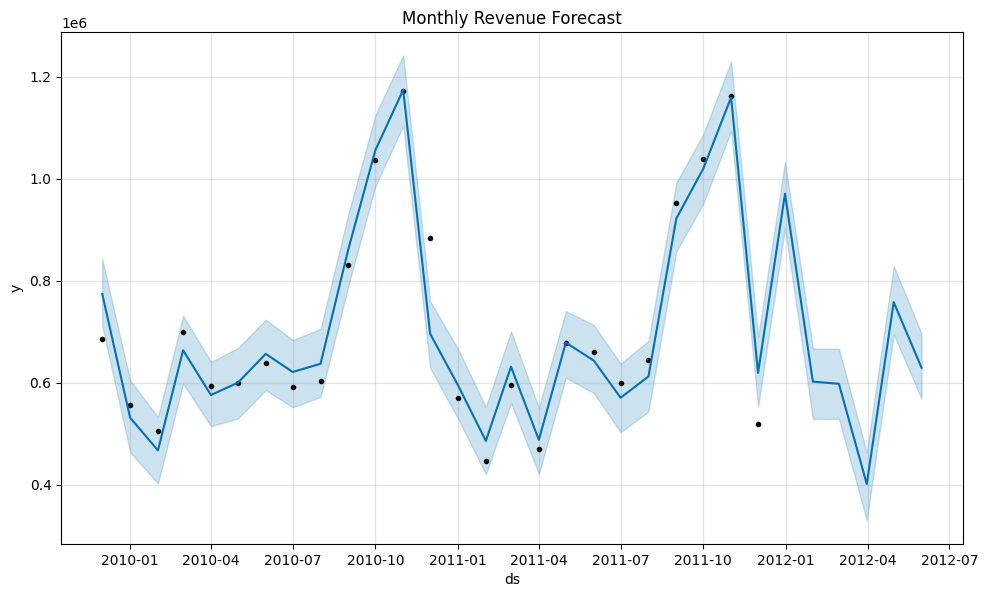

In [9]:
fig = model.plot(forecast)

plt.title("Monthly Revenue Forecast")

plt.show()

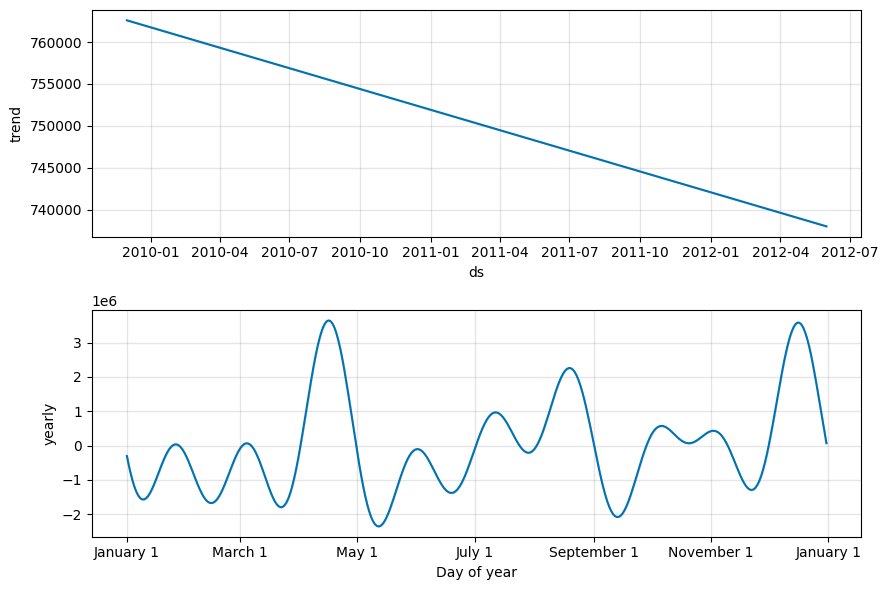

In [10]:
fig2 = model.plot_components(forecast)

plt.show()

In [11]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(6)

,ds,yhat,yhat_lower,yhat_upper
25,2011-12-31,970718.087520,903840.125689,1.033417e+06
26,2012-01-31,602219.029148,528984.117273,6.673147e+05
27,2012-02-29,597916.598409,529337.669881,6.664431e+05
28,2012-03-31,401436.588890,329970.799701,4.634499e+05
29,2012-04-30,758028.627319,695113.190346,8.290601e+05
30,2012-05-31,629384.852727,568312.866973,6.964323e+05


In [12]:
forecast.to_csv(
    "../data/processed/revenue_forecast.csv",
    index=False
)

print("Revenue Forecast Saved Successfully!")

Revenue Forecast Saved Successfully!
